In [2]:
from transformers import DebertaV2ForTokenClassification, AutoTokenizer,  AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

class DebertaNER(nn.Module):
    def __init__(self, tokens_dim):
        super(DebertaNER, self).__init__()
        
        if type(tokens_dim) != int:
            raise TypeError('tokens_dim should be an integer')
        if tokens_dim <= 0:
            raise ValueError('Classification layer dimension should be at least 1')

        self.pretrained = DebertaV2ForTokenClassification.from_pretrained("microsoft/deberta-v3-large", num_labels=tokens_dim)

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass of the network.
        """
        if labels is None:
            return self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
        return self.pretrained(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def save_pretrained(self, save_directory):
        """
        Save the pretrained model to the specified directory.
        """
        self.pretrained.save_pretrained(save_directory)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large", use_fast=True)

print("Tokenizer loaded successfully!")

/home/ritisha21089/.local/lib/python3.8/site-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer loaded successfully!


In [2]:
# Get the vocabulary size
vocab_size = tokenizer.vocab_size

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 128000


In [3]:
text = "1/2 lb spaghetti broken into 2-inch pieces"
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Tokens:", tokens)
print("Token IDs:", token_ids)

Tokens: ['▁1', '/', '2', '▁lb', '▁spaghetti', '▁broken', '▁into', '▁2', '-', 'inch', '▁pieces']
Token IDs: [376, 320, 445, 12446, 22239, 2690, 352, 392, 271, 5043, 1888]


In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large")

text = "1/2 lb spaghetti broken into 2-inch pieces"

# Use the tokenizer to get padded token IDs
encoded = tokenizer(
    text,
    padding='max_length',       # or 'longest' if batching
    max_length=20,              # specify a max length if desired
    truncation=True,            # truncate if longer than max_length
    return_tensors="pt"         # return PyTorch tensors
)

print("Input IDs:", encoded["input_ids"])
print("Attention Mask:", encoded["attention_mask"])

Input IDs: tensor([[    1,   376,   320,   445, 12446, 22239,  2690,   352,   392,   271,
          5043,  1888,     2,     0,     0,     0,     0,     0,     0,     0]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])


In [8]:
import torch
from torch.utils.data import Dataset
import ast

class NerDataset(Dataset):
    """
    Custom dataset class for NER tasks.
    """

    def __init__(self, dataframe, tokenizer, label_map, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # Ensure the 'Ingredient_Phrases' column is a string
        text = str(row['Ingredient_Phrases'])

        # Convert 'Labels' from string representation to a list
        labels_list = ast.literal_eval(row['Labels'])  

        encoding = self.tokenizer(
            text.split(),  # Tokenize word by word
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            is_split_into_words=True  # Ensure token alignment with words
        )

        word_ids = encoding.word_ids(batch_index=0)  # Get token-word alignment
        label_ids = [-100] * self.max_len  # Default to ignored token

        # Assigning NER labels for each word token
        previous_word_id = None
        for i, word_id in enumerate(word_ids):
            if word_id is None:
                label_ids[i] = -100  # Padding or special tokens
            elif word_id != previous_word_id:
                label_ids[i] = self.label_map.get(labels_list[word_id], -100)  # Assign the correct label
            else:
                label_ids[i] = label_ids[i-1]  # For subwords, keep same label
            previous_word_id = word_id

        input_ids = encoding['input_ids'].squeeze(0)  # Remove batch dimension
        attention_mask = encoding['attention_mask'].squeeze(0)  # Remove batch dimension
        label_ids = torch.tensor(label_ids, dtype=torch.long)  # Convert to tensor

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_ids
        }

# Label mapping 
label_map = {
    'QUANTITY': 0,
    'UNIT': 1,
    'NAME': 2,
    'FORM': 3,
    'STATE': 4,
    'DF': 5,
    'SIZE': 6,
    'O': -100  # Outside token or padding
}

from sklearn.model_selection import train_test_split
df = pd.read_csv('../../data/processed/10k_data_modified.csv')

- train + test split 

In [9]:
#ner_dataset = NerDataset(df, tokenizer, label_map)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

- train test val split

In [5]:
#ner_dataset = NerDataset(df, tokenizer, label_map)
#ner_dataset = NerDataset(df, tokenizer, label_map)
train_df_, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df_, test_size=0.2, random_state=42)

train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
val_dataset = NerDataset(dataframe=val_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [10]:
model = DebertaNER(tokens_dim=len(label_map))
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training settings
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.train()

Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/ritisha21089/.local/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


DebertaNER(
  (pretrained): DebertaV2ForTokenClassification(
    (deberta): DebertaV2Model(
      (embeddings): DebertaV2Embeddings(
        (word_embeddings): Embedding(128100, 1024, padding_idx=0)
        (LayerNorm): LayerNorm((1024,), eps=1e-07, elementwise_affine=True)
        (dropout): StableDropout()
      )
      (encoder): DebertaV2Encoder(
        (layer): ModuleList(
          (0-23): 24 x DebertaV2Layer(
            (attention): DebertaV2Attention(
              (self): DisentangledSelfAttention(
                (query_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (key_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (value_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (pos_dropout): StableDropout()
                (dropout): StableDropout()
              )
              (output): DebertaV2SelfOutput(
                (dense): Linear(in_features=1024, out_features=1024, bias=True)
 

In [5]:
import torch
torch.cuda.set_device(1)  # Set GPU 1 as the active device
print("Now using GPU:", torch.cuda.current_device())

Now using GPU: 1


# MODEL TRAINING

- validation + training 

Epoch 1/5 [Training]: 100%|██████████| 432/432 [02:37<00:00,  2.75it/s, Train Loss=0.0184]


Epoch 1/5, Train Loss: 0.2215, Val Loss: 0.0825


Epoch 2/5 [Training]: 100%|██████████| 432/432 [02:38<00:00,  2.73it/s, Train Loss=0.0038]


Epoch 2/5, Train Loss: 0.0636, Val Loss: 0.0685


Epoch 3/5 [Training]: 100%|██████████| 432/432 [02:38<00:00,  2.73it/s, Train Loss=0.0051]


Epoch 3/5, Train Loss: 0.0427, Val Loss: 0.0779


Epoch 4/5 [Training]: 100%|██████████| 432/432 [02:59<00:00,  2.40it/s, Train Loss=0.0012]


Epoch 4/5, Train Loss: 0.0330, Val Loss: 0.0810


Epoch 5/5 [Training]: 100%|██████████| 432/432 [02:38<00:00,  2.73it/s, Train Loss=0.0132]


Epoch 5/5, Train Loss: 0.0257, Val Loss: 0.0760


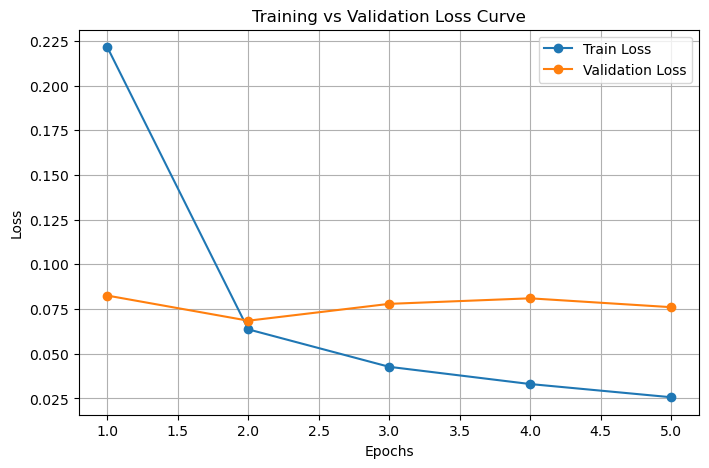

In [7]:
import matplotlib.pyplot as plt
from tqdm import tqdm  # Import tqdm for progress bars

# Lists to store losses
train_losses = []
val_losses = []

for epoch in range(epochs):
    total_train_loss = 0
    total_val_loss = 0

    # Training phase
    model.train()
    train_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")  

    for batch in train_iterator:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_iterator.set_postfix({"Train Loss": f"{loss.item():.4f}"})  # Update tqdm bar

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase (no gradient updates)
    model.eval()
    val_iterator = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

    with torch.no_grad():
        for batch in val_iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            total_val_loss += loss.item()
            val_iterator.set_postfix({"Val Loss": f"{loss.item():.4f}"})  # Update tqdm bar

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Plot Training vs Validation Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss", marker='o', linestyle='-')
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()
plt.show()

- early stopping + training

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

# Train
train_losses = []
val_losses = []
patience = 3  # Stop training if validation loss does not improve for 'patience' epochs
best_val_loss = np.inf  # Initialize best validation loss as infinity
early_stop_counter = 0  # Tracks epochs without improvement
epochs = 8

for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    # Training Loop
    model.train()
    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Update tqdm description with latest loss
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)  # Store training loss

    # Validation Step
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:  # Assuming you have a validation DataLoader
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)  # Store validation loss

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss  # Update best validation loss
        early_stop_counter = 0  # Reset counter
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stop_counter += 1
        print(f"Early stopping counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Early stopping triggered! Stopping training.")
        break  # Stop training

- cross fold validation


------------------------------
Fold 1/5
------------------------------


Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1/5 [Validation]:   0%|          | 0/135 [00:00<?, ?it/s]                      

Epoch 1/5 - Train Loss: 0.1397, Val Loss: 0.0641


Epoch 2/5 - Train Loss: 0.0544, Val Loss: 0.0758


Epoch 3/5 [Validation]:   0%|          | 0/135 [00:00<?, ?it/s]                      

...

Epoch 3/5 [Validation]:   0%|          | 0/135 [00:00<?, ?it/s]                      

Epoch 3/5 - Train Loss: 0.0391, Val Loss: 0.0763


Epoch 4/5 - Train Loss: 0.0308, Val Loss: 0.0760


Epoch 5/5 [Validation]:   0%|          | 0/135 [00:00<?, ?it/s]                       

Epoch 5/5 - Train Loss: 0.0242, Val Loss: 0.0859

Classification Report for Fold:
              precision    recall  f1-score   support

           0     0.9952    0.9984    0.9968      3755
           1     0.9896    0.9873    0.9884      1727
           2     0.9706    0.9899    0.9802      3775
           3     0.9344    0.8792    0.9060       778
           4     0.9805    0.9755    0.9780      2163
           5     0.9953    0.9505    0.9724       222
           6     0.9798    0.9518    0.9656       560

    accuracy                         0.9807     12980
   macro avg     0.9779    0.9618    0.9696     12980
weighted avg     0.9806    0.9807    0.9805     12980



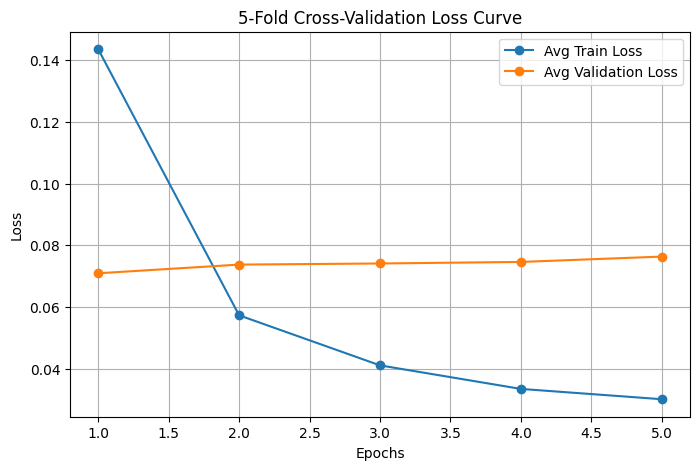

In [21]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold  # To check for imbalance
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm  # Import tqdm for progress bars

k_folds = 5  # Number of folds
batch_size = 16
epochs = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Convert DataFrame to NumPy for indexing
df_np = df.to_numpy()
fold_results = []

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# for fold, (train_idx, val_idx) in enumerate(skf.split(df_np, df["Labels"])):  # Use your label column

for fold, (train_idx, val_idx) in enumerate(kf.split(df_np)):
    print(f"\n{'-'*30}\nFold {fold+1}/{k_folds}\n{'-'*30}")

    train_df = pd.DataFrame(df_np[train_idx], columns=df.columns)
    val_df = pd.DataFrame(df_np[val_idx], columns=df.columns)

    # Create datasets
    train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
    val_dataset = NerDataset(dataframe=val_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = DebertaNER(tokens_dim=len(label_map)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    # Training loop
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        total_train_loss = 0
        total_val_loss = 0

        # Training phase with tqdm
        model.train()
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)

        for batch in train_bar:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase with tqdm
        model.eval()
        all_preds = []
        all_labels = []

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                logits = outputs.logits  # Ensure logits are present

                predictions = torch.argmax(logits, dim=-1)
                
                # # Store predictions and labels
                # all_preds.extend(predictions.cpu().numpy().flatten())  
                # all_labels.extend(labels.cpu().numpy().flatten())  

                for p_seq, l_seq in zip(predictions, labels):
                    p_seq = p_seq.cpu().numpy()
                    l_seq = l_seq.cpu().numpy()
                    for p, l in zip(p_seq, l_seq):
                        if l != -100:
                            all_preds.append(p)
                            all_labels.append(l)

                loss = outputs.loss
                total_val_loss += loss.item()
    
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Print classification report
    print("\nClassification Report for Fold:")
    print(classification_report(all_labels, all_preds, digits=4))

    fold_results.append({
        'train_losses': train_losses, 
        'val_losses': val_losses,
        'classification_report': classification_report(all_labels, all_preds, digits=4, output_dict=True)
    })

# Aggregate results from all folds
avg_train_loss_per_epoch = np.mean([fold['train_losses'] for fold in fold_results], axis=0)
avg_val_loss_per_epoch = np.mean([fold['val_losses'] for fold in fold_results], axis=0)

# Plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), avg_train_loss_per_epoch, label="Avg Train Loss", marker='o', linestyle='-')
plt.plot(range(1, epochs + 1), avg_val_loss_per_epoch, label="Avg Validation Loss", marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"{k_folds}-Fold Cross-Validation Loss Curve")
plt.legend()
plt.grid()
plt.show()

In [6]:
ner_dataset = NerDataset(dataframe=df, tokenizer=tokenizer, label_map=label_map, max_len=128)

Fold 1/5
Epoch 1/5, Training Loss: 0.1362
Epoch 1/5, Validation Loss: 0.0720
Epoch 2/5, Training Loss: 0.0503
Epoch 2/5, Validation Loss: 0.0663
Epoch 3/5, Training Loss: 0.0349
Epoch 3/5, Validation Loss: 0.0662
Epoch 4/5, Training Loss: 0.0240
Epoch 4/5, Validation Loss: 0.0696
Epoch 5/5, Training Loss: 0.0166
Epoch 5/5, Validation Loss: 0.0761
Fold 1 - Precision: 0.9756, Recall: 0.9762, F1-Score: 0.9759
Classification Report for Fold 1:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3709
           1       0.99      1.00      0.99      1720
           2       0.97      0.99      0.98      3705
           3       0.93      0.92      0.93       842
           4       0.99      0.96      0.98      2222
           5       0.97      1.00      0.99       186
           6       0.97      0.96      0.97       535

    accuracy                           0.98     12919
   macro avg       0.98      0.98      0.98     12919
weighted avg 

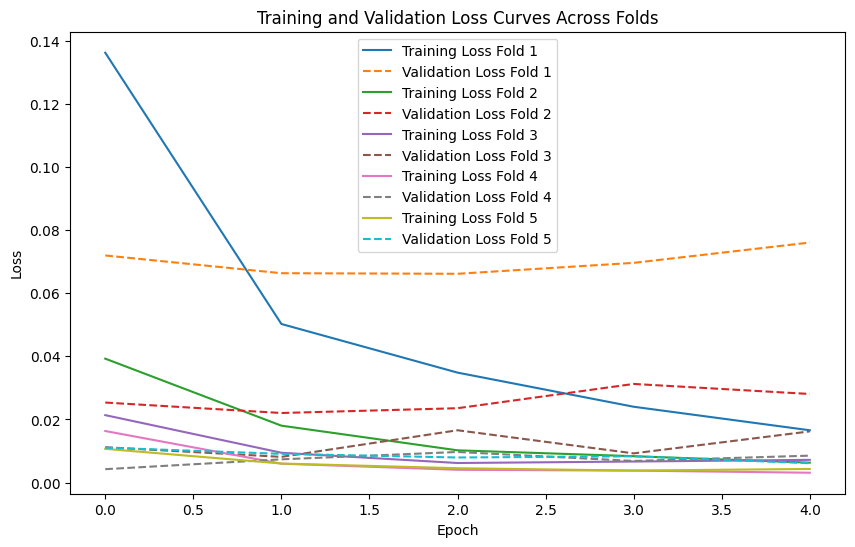

In [6]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

k_folds = 5

# Initialize KFold
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Lists to store metrics for each fold
all_precisions = []
all_recalls = []
all_f1_scores = []
fold_loss_history = []  # Store loss for each epoch in each fold
val_loss_history = []  # Store validation loss for each epoch in each fold

for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Subset the dataset for train and validation based on indices
    train_dataset = Subset(ner_dataset, train_idx)
    val_dataset = Subset(ner_dataset, val_idx)
    
    # Create DataLoader for train and validation
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # Train the model
    model.train()
    epoch_loss = []  # Track the loss for each epoch
    epoch_val_loss = []  # Track validation loss for each epoch

    for epoch in range(epochs):
        total_loss = 0
        total_val_loss = 0  # For tracking validation loss

        # Training loop
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Calculate the average training loss
        avg_loss = total_loss / len(train_loader)
        epoch_loss.append(avg_loss)  # Store loss for this epoch
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_loss:.4f}")

        # Validation loop
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                # Forward pass
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss = outputs.loss

                total_val_loss += val_loss.item()

        # Calculate the average validation loss
        avg_val_loss = total_val_loss / len(val_loader)
        epoch_val_loss.append(avg_val_loss)  # Store validation loss for this epoch
        print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {avg_val_loss:.4f}")

    fold_loss_history.append(epoch_loss)  # Store loss history for this fold
    val_loss_history.append(epoch_val_loss)  # Store validation loss history for this fold

    # Evaluation on the validation set
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            logits = logits.detach().cpu().numpy()
            label_ids = labels.cpu().numpy()

            for i in range(len(label_ids)):
                pred_labels = []
                true_label = []
                for j in range(len(label_ids[i])):
                    if label_ids[i][j] != -100:  # Ignoring padding or special tokens
                        true_label.append(label_ids[i][j])
                        pred_label = np.argmax(logits[i][j])
                        pred_labels.append(pred_label)
                predictions.append(pred_labels)
                true_labels.append(true_label)

    # Flatten predictions and true labels
    flat_predictions = [item for sublist in predictions for item in sublist]
    flat_true_labels = [item for sublist in true_labels for item in sublist]

    # Calculate metrics for this fold
    precision = precision_score(flat_true_labels, flat_predictions, average='macro')
    recall = recall_score(flat_true_labels, flat_predictions, average='macro')
    f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

    # Store metrics for this fold
    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1_scores.append(f1)

    print(f"Fold {fold + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Print classification report for this fold
    print(f"Classification Report for Fold {fold + 1}:\n")
    print(classification_report(flat_true_labels, flat_predictions))

# After cross-validation, calculate average metrics
avg_precision = np.mean(all_precisions)
avg_recall = np.mean(all_recalls)
avg_f1 = np.mean(all_f1_scores)

print(f"\nCross-Validation Results ({k_folds} Folds):")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-Score: {avg_f1:.4f}")

# Plot loss curves for each fold (training and validation)
plt.figure(figsize=(10, 6))
for fold_idx in range(k_folds):
    plt.plot(fold_loss_history[fold_idx], label=f'Training Loss Fold {fold_idx + 1}')
    plt.plot(val_loss_history[fold_idx], linestyle='--', label=f'Validation Loss Fold {fold_idx + 1}')
plt.title('Training and Validation Loss Curves Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [4]:
!pip install iterative-stratification

In [8]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch
import matplotlib.pyplot as plt

# Hyperparameters
k_folds = 5
batch_size = 16
epochs = 5

# Convert list of labels to binary matrix (for multi-label stratification)
mlb = MultiLabelBinarizer()
y_bin = mlb.fit_transform(df['Labels'])

# Dataset
ner_dataset = NerDataset(dataframe=df, tokenizer=tokenizer, label_map=label_map, max_len=128)

# Initialize the splitter
mskf = MultilabelStratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# For storing metrics
all_precisions, all_recalls, all_f1_scores = [], [], []
fold_loss_history, val_loss_history = [], []

for fold, (train_idx, val_idx) in enumerate(mskf.split(df, y_bin)):
    print(f"\nFold {fold + 1}/{k_folds}")
    
    # Initialize model and optimizer from scratch
    model = DebertaNER(tokens_dim=len(label_map)).to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # Subset dataset and create loaders
    train_dataset = Subset(ner_dataset, train_idx)
    val_dataset = Subset(ner_dataset, val_idx)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epoch_loss = []
    epoch_val_loss = []

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        epoch_loss.append(avg_loss)
        print(f"Epoch {epoch+1} - Training Loss: {avg_loss:.4f}")

        # Validation loop
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                total_val_loss += outputs.loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        epoch_val_loss.append(avg_val_loss)
        print(f"Epoch {epoch+1} - Validation Loss: {avg_val_loss:.4f}")

    fold_loss_history.append(epoch_loss)
    val_loss_history.append(epoch_val_loss)

    # Evaluation
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.cpu().numpy()
            label_ids = labels.cpu().numpy()

            for i in range(len(label_ids)):
                pred_labels = []
                true_label = []
                for j in range(len(label_ids[i])):
                    if label_ids[i][j] != -100:
                        true_label.append(label_ids[i][j])
                        pred_labels.append(np.argmax(logits[i][j]))
                true_labels.append(true_label)
                predictions.append(pred_labels)

    # Flatten for metrics
    flat_preds = [p for seq in predictions for p in seq]
    flat_trues = [t for seq in true_labels for t in seq]

    # Scores
    precision = precision_score(flat_trues, flat_preds, average='macro')
    recall = recall_score(flat_trues, flat_preds, average='macro')
    f1 = f1_score(flat_trues, flat_preds, average='macro')

    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1_scores.append(f1)

    print(f"Fold {fold + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(classification_report(flat_trues, flat_preds))

# Final average scores
print("\nCross-Validation Summary:")
print(f"Average Precision: {np.mean(all_precisions):.4f}")
print(f"Average Recall: {np.mean(all_recalls):.4f}")
print(f"Average F1: {np.mean(all_f1_scores):.4f}")

# Plotting
plt.figure(figsize=(10, 6))
for i in range(k_folds):
    plt.plot(fold_loss_history[i], label=f'Train Loss Fold {i+1}')
    plt.plot(val_loss_history[i], linestyle='--', label=f'Val Loss Fold {i+1}')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Per Fold")
plt.legend()
plt.show()


Fold 1/5


Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1 - Training Loss: 0.1290
Epoch 1 - Validation Loss: 0.0735
Epoch 2 - Training Loss: 0.0544
Epoch 2 - Validation Loss: 0.0716
Epoch 3 - Training Loss: 0.0389
Epoch 3 - Validation Loss: 0.0808
Epoch 4 - Training Loss: 0.0348
Epoch 4 - Validation Loss: 0.0721
Epoch 5 - Training Loss: 0.0232
Epoch 5 - Validation Loss: 0.0758
Fold 1 - Precision: 0.9695, Recall: 0.9746, F1: 0.9719
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3713
           1       0.99      0.99      0.99      1725
           2       0.99      0.98      0.99      3793
           3       0.90      0.96      0.93       823
           4       0.98      0.98      0.98      2121
           5       0.99      0.98      0.98       224
           6       0.94      0.95      0.94       534

    accuracy                           0.98     12933
   macro avg       0.97      0.97      0.97     12933
weighted avg       0.98      0.98      0.98     12933


Fold 2/5


Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1 - Training Loss: 0.2990
Epoch 1 - Validation Loss: 0.4223
Epoch 2 - Training Loss: 0.8601
Epoch 2 - Validation Loss: 1.7557
Epoch 3 - Training Loss: 1.2755
Epoch 3 - Validation Loss: 1.8578
Epoch 4 - Training Loss: 1.2375
Epoch 4 - Validation Loss: 1.7435
Epoch 5 - Training Loss: 1.2274
Epoch 5 - Validation Loss: 1.7051


/home/ritisha21089/miniconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Fold 2 - Precision: 0.0412, Recall: 0.1429, F1: 0.0640
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3788
           1       0.00      0.00      0.00      1718
           2       0.29      1.00      0.45      3770
           3       0.00      0.00      0.00       854
           4       0.00      0.00      0.00      2194
           5       0.00      0.00      0.00       218
           6       0.00      0.00      0.00       525

    accuracy                           0.29     13067
   macro avg       0.04      0.14      0.06     13067
weighted avg       0.08      0.29      0.13     13067


Fold 3/5


Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1 - Training Loss: 0.1523
Epoch 1 - Validation Loss: 0.0659


KeyboardInterrupt: 

- Training

In [11]:
from tqdm import tqdm

# Train
train_losses = []

for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Update tqdm description with the latest loss
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)  # Store loss

    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

Epoch 1/5:   0%|          | 0/540 [00:00<?, ?it/s]

Epoch 1/5, Average Loss: 0.1525


Epoch 2/5, Average Loss: 0.0555


Epoch 3/5, Average Loss: 0.0427


Epoch 4/5, Average Loss: 0.0322


Epoch 5/5, Average Loss: 0.0262


# EVALUATION

In [12]:
# Evaluation 
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

- runnng for bucket analysis

In [13]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print("DeBERTa-v3-large results: ")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

DeBERTa-v3-large results: 
Precision: 0.9676
Recall: 0.9801
F1-Score: 0.9736
              precision    recall  f1-score   support

           0     0.9995    0.9879    0.9936      3709
           1     0.9908    0.9971    0.9939      1720
           2     0.9830    0.9827    0.9829      3705
           3     0.9352    0.9252    0.9301       842
           4     0.9801    0.9752    0.9777      2222
           5     0.9738    1.0000    0.9867       186
           6     0.9108    0.9925    0.9499       535

    accuracy                         0.9817     12919
   macro avg     0.9676    0.9801    0.9736     12919
weighted avg     0.9820    0.9817    0.9818     12919



In [7]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print("DeBERTa-v3-large results: ")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

DeBERTa-v3-large results: 
Precision: 0.9770
Recall: 0.9728
F1-Score: 0.9747
              precision    recall  f1-score   support

           0     0.9946    0.9978    0.9962      3709
           1     0.9868    0.9965    0.9916      1720
           2     0.9724    0.9895    0.9809      3705
           3     0.9546    0.8990    0.9260       842
           4     0.9867    0.9680    0.9773      2222
           5     0.9688    1.0000    0.9841       186
           6     0.9753    0.9589    0.9670       535

    accuracy                         0.9821     12919
   macro avg     0.9770    0.9728    0.9747     12919
weighted avg     0.9821    0.9821    0.9820     12919



In [7]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print("DeBERTa-v3-large results: ")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

DeBERTa-v3-large results: 
Precision: 0.9769
Recall: 0.9796
F1-Score: 0.9782
              precision    recall  f1-score   support

           0     0.9994    0.9978    0.9986      3637
           1     0.9959    0.9964    0.9962      1690
           2     0.9837    0.9813    0.9825      3746
           3     0.9369    0.9209    0.9288       822
           4     0.9769    0.9836    0.9802      2189
           5     0.9813    0.9953    0.9882       211
           6     0.9645    0.9819    0.9731       553

    accuracy                         0.9847     12848
   macro avg     0.9769    0.9796    0.9782     12848
weighted avg     0.9847    0.9847    0.9847     12848



# MODEL SAVING 

In [8]:
import torch

# Define checkpoint path
checkpoint_path = "../../models/deberta_v3_large/deberta_v3_large_ner.pth"

# Save the model and optimizer state
torch.save({
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, checkpoint_path)

print(f"Checkpoint saved at {checkpoint_path}")

Checkpoint saved at deberta_v3_large_ner.pth


In [10]:
import pandas as pd

df_results = pd.DataFrame({
    "True_Label": flat_true_labels,
    "Predicted_Label": flat_predictions
})

df_results.to_csv("../../results/deberta_v3_large_ner_predictions.csv", index=False)
print("Predictions saved to deberta_v3_large_ner_predictions.csv!")

Predictions saved to deberta_v3_large_ner_predictions.csv!


In [9]:
import torch

# Define test dataset save path
test_dataset_path = "../../models/deberta_v3_large/test_loader_deberta_v3_large.pth"

# Save the dataset (which is used in test_loader)
torch.save(test_dataset, test_dataset_path)

print(f"Test dataset saved at {test_dataset_path}")

Test dataset saved at test_loader_deberta_v3_large.pth


# Loading model

In [4]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Define checkpoint path
checkpoint_path = "../../models/deberta_v3_large/deberta_v3_large_ner.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DebertaNER(tokens_dim=len(label_map))
optimizer = AdamW(model.parameters(), lr=2e-5)

# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)


# Load model and optimizer state
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Ensure model is in evaluation mode
model.to(device)
model.eval()

print("Model loaded successfully and set to evaluation mode!")

Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
/tmp/ipykernel_2927919/4265313921.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models f

Model loaded successfully and set to evaluation mode!


In [5]:
predictions = []
true_labels = []

batch_size = 16
test_dataset_path = "../../models/deberta_v3_large/test_loader_deberta_v3_large.pth"
test_dataset = torch.load(test_dataset_path)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
print("Test loader reloaded successfully!")

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:  # Ignore padding labels
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

flat_predictions_new = [item for sublist in predictions for item in sublist]
flat_true_labels_new = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels_new, flat_predictions_new, average='macro')
recall = recall_score(flat_true_labels_new, flat_predictions_new, average='macro')
f1 = f1_score(flat_true_labels_new, flat_predictions_new, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels_new, flat_predictions_new, digits=4)
print(report)

/tmp/ipykernel_2927919/4281528962.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_dataset = torch.load(test_dataset_path)


Test loader reloaded successfully!
Precision: 0.9769
Recall: 0.9796
F1-Score: 0.9782
              precision    recall  f1-score   support

           0     0.9994    0.9978    0.9986      3637
           1     0.9959    0.9964    0.9962      1690
           2     0.9837    0.9813    0.9825      3746
           3     0.9369    0.9209    0.9288       822
           4     0.9769    0.9836    0.9802      2189
           5     0.9813    0.9953    0.9882       211
           6     0.9645    0.9819    0.9731       553

    accuracy                         0.9847     12848
   macro avg     0.9769    0.9796    0.9782     12848
weighted avg     0.9847    0.9847    0.9847     12848



In [20]:
from scipy.stats import spearmanr

# Step 1: Label frequency from support (based on your screenshot)
label_frequencies = {
    'QUANTITY': 3637,
    'UNIT': 1690,
    'NAME': 3746,
    'FORM': 822,
    'STATE': 2189,
    'DF': 211,
    'SIZE': 553,
    'O': 0  # Excluded
}

# Step 2: F1-scores from your classification report
label_f1_scores = {
    'QUANTITY': 0.9986,
    'UNIT': 0.9962,
    'NAME': 0.9825,
    'FORM': 0.9288,
    'STATE': 0.9802,
    'DF': 0.9882,
    'SIZE': 0.9731,
}

# Step 3: Prepare ordered lists
entities = list(label_f1_scores.keys())
frequencies = [label_frequencies[ent] for ent in entities]
f1_scores = [label_f1_scores[ent] for ent in entities]

# Step 4: Spearman correlation
rho, pval = spearmanr(frequencies, f1_scores)
print(f"Spearman correlation (ρ): {rho:.4f}, p-value: {pval:.4f}")

Spearman correlation (ρ): 0.3214, p-value: 0.4821


- auc-roc plot

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Define usable label indices (exclude -100 for 'O')
valid_label_indices = list(label_map.values())
valid_label_indices.remove(-100)  # Exclude 'O'/'PAD'

# Flatten true and predicted labels
flat_trues = []
flat_preds = []

for true_seq, pred_seq in zip(true_labels, predictions):
    for t, p in zip(true_seq, pred_seq):
        if t != -100:
            flat_trues.append(t)
            flat_preds.append(p)

# Binarize (One-hot encoding) for ROC analysis
y_true_bin = label_binarize(flat_trues, classes=valid_label_indices)
y_pred_bin = label_binarize(flat_preds, classes=valid_label_indices)

In [11]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for idx, label in enumerate(valid_label_indices):
    fpr[label], tpr[label], _ = roc_curve(y_true_bin[:, idx], y_pred_bin[:, idx])
    roc_auc[label] = auc(fpr[label], tpr[label])

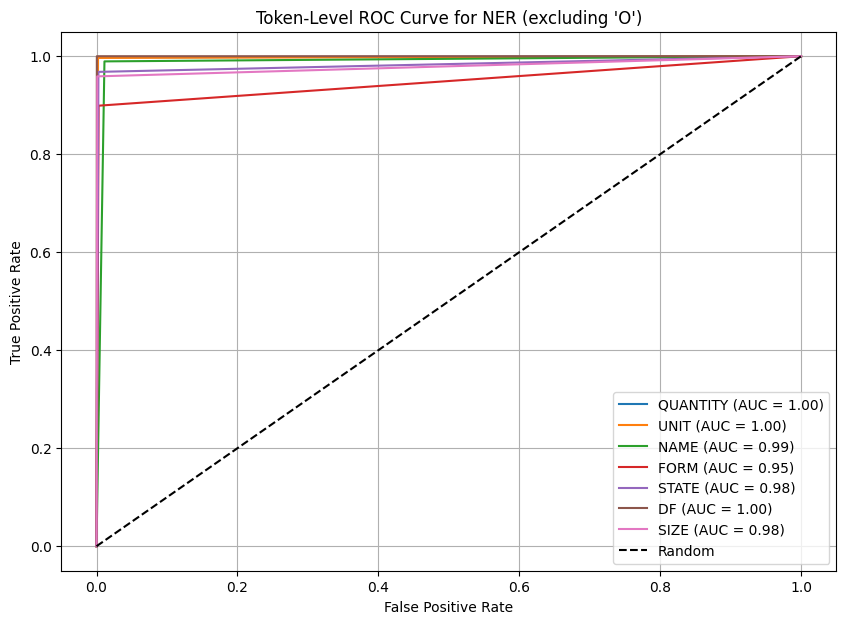

In [12]:
# Inverse label_map to get names
inv_label_map = {v: k for k, v in label_map.items() if v != -100}

plt.figure(figsize=(10, 7))
for label in valid_label_indices:
    plt.plot(fpr[label], tpr[label], label=f"{inv_label_map[label]} (AUC = {roc_auc[label]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Token-Level ROC Curve for NER (excluding 'O')")
plt.legend(loc="lower right")
plt.grid()
plt.show()

- error analysis

              precision    recall  f1-score       support
0              0.994625  0.997843  0.996231   3709.000000
1              0.986759  0.996512  0.991611   1720.000000
2              0.972414  0.989474  0.980870   3705.000000
3              0.954603  0.899050  0.925994    842.000000
4              0.986697  0.968047  0.977283   2222.000000
5              0.968750  1.000000  0.984127    186.000000
6              0.975285  0.958879  0.967012    535.000000
accuracy       0.982119  0.982119  0.982119      0.982119
macro avg      0.977019  0.972829  0.974733  12919.000000
weighted avg   0.982062  0.982119  0.981990  12919.000000


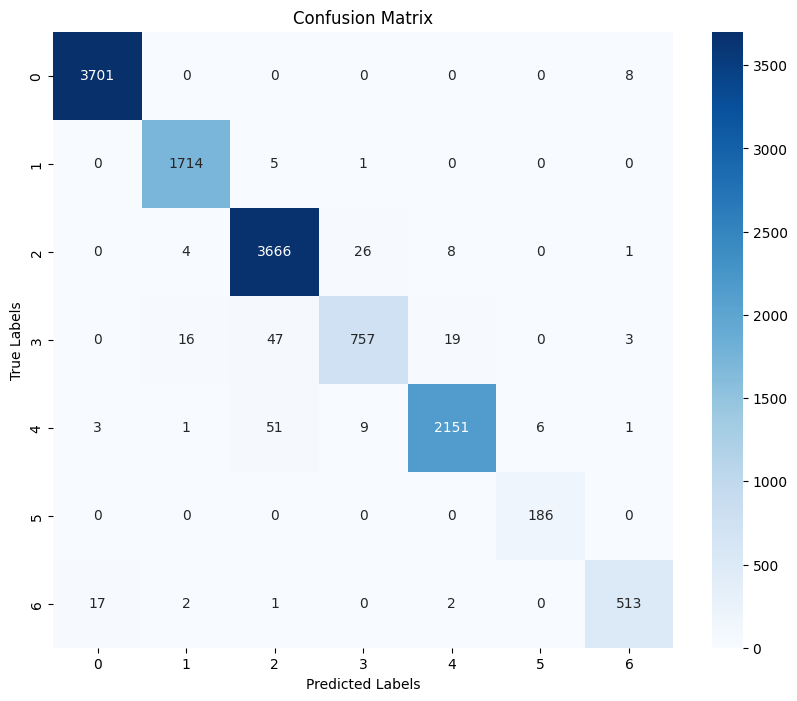

Total Misclassified Examples: 231
Sample Misclassified Examples:
True: 4, Predicted: 2
True: 2, Predicted: 3
True: 3, Predicted: 4
True: 3, Predicted: 4
True: 2, Predicted: 3
True: 4, Predicted: 2
True: 3, Predicted: 2
True: 2, Predicted: 3
True: 4, Predicted: 2
True: 4, Predicted: 2

Misclassification Frequency:
True Label  Predicted Label
4           2                  51
3           2                  47
2           3                  26
3           4                  19
6           0                  17
3           1                  16
4           3                   9
0           6                   8
2           4                   8
4           5                   6
1           2                   5
2           1                   4
3           6                   3
4           0                   3
6           1                   2
            4                   2
4           1                   1
2           6                   1
4           6                   1
1          

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming flat_predictions and flat_true_labels are already defined

# Generate Classification Report
report = classification_report(flat_true_labels, flat_predictions, digits=4, output_dict=True)
print(pd.DataFrame(report).transpose())  # Display the detailed report

# Confusion Matrix
conf_matrix = confusion_matrix(flat_true_labels, flat_predictions)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(flat_true_labels),
            yticklabels=np.unique(flat_true_labels)) 
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Error Analysis: Misclassified Examples
errors = [(true, pred) for true, pred in zip(flat_true_labels, flat_predictions) if true != pred]
print(f"Total Misclassified Examples: {len(errors)}")
print("Sample Misclassified Examples:")
for i, (true, pred) in enumerate(errors[:10]):  # Show first 10 errors
    print(f"True: {true}, Predicted: {pred}")

# Class-wise Error Analysis
error_counts = pd.DataFrame(errors, columns=['True Label', 'Predicted Label']).value_counts()
print("\nMisclassification Frequency:")
print(error_counts)

- bucket analysis

In [19]:
import numpy as np
import pandas as pd

# Ensuring string conversion for 'Ingredient_Phrases'
df['Ingredient_Phrases'] = df['Ingredient_Phrases'].fillna('').astype(str)

# Calculating entity lengths and creating buckets
df['Entity_Length'] = df['Ingredient_Phrases'].apply(lambda x: len(x.split()))
df['Entity_Length_Bucket'] = pd.cut(
    df['Entity_Length'], 
    bins=[0, 4, 8, 12, np.inf],
    labels=['very_short', 'short', 'medium', 'long']
)

# Label frequency normalization
label_freq = df['Labels'].explode().value_counts(normalize=True)
df['Label_Consistency'] = df['Labels'].apply(lambda x: label_freq.get(x, 0))
df['Label_Consistency_Bucket'] = pd.cut(
    df['Label_Consistency'], 
    bins=[0.0, 0.0000935, 0.0005, 0.01, np.inf],
    labels=['very_rare', 'rare', 'common', 'very_common']
)

# Token frequency normalization
token_freq = df['Ingredient_Phrases'].str.split().explode().value_counts(normalize=True)
df['Token_Frequency'] = df['Ingredient_Phrases'].apply(
    lambda x: np.mean([token_freq.get(token, 0) for token in x.split()])
)
df['Token_Frequency_Bucket'] = pd.cut(
    df['Token_Frequency'], 
    bins=[0.0, 0.00002, 0.00005, 0.0003, np.inf],
    labels=['rare', 'moderate', 'frequent', 'very_frequent']
)

# Ensuring no NaN in buckets
df['Entity_Length_Bucket'] = df['Entity_Length_Bucket'].cat.add_categories('unknown').fillna('unknown')
df['Label_Consistency_Bucket'] = df['Label_Consistency_Bucket'].cat.add_categories('unknown').fillna('unknown')
df['Token_Frequency_Bucket'] = df['Token_Frequency_Bucket'].cat.add_categories('unknown').fillna('unknown')

In [15]:
print(df['Entity_Length'].describe())

count    10784.000000
mean         7.967359
std          3.892992
min          1.000000
25%          5.000000
50%          7.000000
75%         10.000000
max         42.000000
Name: Entity_Length, dtype: float64


In [16]:
print(label_freq.describe())

count    4120.000000
mean        0.000243
std         0.000936
min         0.000093
25%         0.000093
50%         0.000093
75%         0.000185
max         0.036999
Name: Labels, dtype: float64


In [17]:
print(token_freq.describe())

count    4458.000000
mean        0.000224
std         0.001700
min         0.000012
25%         0.000012
50%         0.000023
75%         0.000070
max         0.070577
Name: Ingredient_Phrases, dtype: float64


In [20]:
from sklearn.metrics import classification_report

# Evaluating per bucket
def evaluate_bucket_performance(df, y_true, y_pred, bucket_column):
    unique_buckets = df[bucket_column].unique()
    for bucket in unique_buckets:
        bucket_indices = df[df[bucket_column] == bucket].index
        y_true_bucket = [y_true[i] for i in bucket_indices]
        y_pred_bucket = [y_pred[i] for i in bucket_indices]
        print(f"Performance for {bucket_column}: {bucket}")
        print(classification_report(y_true_bucket, y_pred_bucket, digits=4))


evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Entity_Length_Bucket')
evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Label_Consistency_Bucket')
evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Token_Frequency_Bucket')

Performance for Entity_Length_Bucket: very_short
              precision    recall  f1-score   support

           0     1.0000    0.9978    0.9989       465
           1     0.9865    1.0000    0.9932       220
           2     0.9728    0.9915    0.9820       469
           3     0.9667    0.8529    0.9062       102
           4     0.9854    0.9747    0.9800       277
           5     0.8750    1.0000    0.9333        21
           6     0.9870    1.0000    0.9935        76

    accuracy                         0.9834      1630
   macro avg     0.9676    0.9739    0.9696      1630
weighted avg     0.9836    0.9834    0.9832      1630

Performance for Entity_Length_Bucket: medium
              precision    recall  f1-score   support

           0     0.9893    1.0000    0.9946       740
           1     0.9863    0.9917    0.9890       362
           2     0.9712    0.9933    0.9821       746
           3     0.9760    0.9157    0.9449       178
           4     0.9894    0.9649    0

- new bucket analysis

In [17]:
import numpy as np
import pandas as pd

# Ensuring string conversion for 'Ingredient_Phrases'
df['Ingredient_Phrases'] = df['Ingredient_Phrases'].fillna('').astype(str)

# Calculating entity lengths and creating buckets
df['Entity_Length'] = df['Ingredient_Phrases'].apply(lambda x: len(x.split()))
df['Entity_Length_Bucket'] = pd.cut(
    df['Entity_Length'], 
    bins = [0, 6, 10, np.inf],
    labels = ['short', 'medium', 'long']
)

# Label frequency normalization
label_freq = df['Labels'].explode().value_counts(normalize=True)
df['Label_Consistency'] = df['Labels'].apply(lambda x: label_freq.get(x, 0))
df['Label_Consistency_Bucket'] = pd.cut(
    df['Label_Consistency'], 
    bins = [0.0, 0.0000935, 0.001, np.inf],
    labels = ['rare', 'common', 'very_common']
)

# Token frequency normalization
token_freq = df['Ingredient_Phrases'].str.split().explode().value_counts(normalize=True)
df['Token_Frequency'] = df['Ingredient_Phrases'].apply(
    lambda x: np.mean([token_freq.get(token, 0) for token in x.split()])
)
df['Token_Frequency_Bucket'] = pd.cut(
    df['Token_Frequency'], 
    bins = [0.0, 0.00003, 0.0001, np.inf],
    labels = ['rare', 'frequent', 'very_frequent']
)

# Ensuring no NaN in buckets
df['Entity_Length_Bucket'] = df['Entity_Length_Bucket'].cat.add_categories('unknown').fillna('unknown')
df['Label_Consistency_Bucket'] = df['Label_Consistency_Bucket'].cat.add_categories('unknown').fillna('unknown')
df['Token_Frequency_Bucket'] = df['Token_Frequency_Bucket'].cat.add_categories('unknown').fillna('unknown')

In [18]:
from sklearn.metrics import classification_report

# Evaluating per bucket
def evaluate_bucket_performance(df, y_true, y_pred, bucket_column):
    unique_buckets = df[bucket_column].unique()
    for bucket in unique_buckets:
        bucket_indices = df[df[bucket_column] == bucket].index
        y_true_bucket = [y_true[i] for i in bucket_indices]
        y_pred_bucket = [y_pred[i] for i in bucket_indices]
        print(f"Performance for {bucket_column}: {bucket}")
        print(classification_report(y_true_bucket, y_pred_bucket, digits=4))


evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Entity_Length_Bucket')
evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Label_Consistency_Bucket')
evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Token_Frequency_Bucket')

Performance for Entity_Length_Bucket: short
              precision    recall  f1-score   support

           0     1.0000    0.9857    0.9928      1262
           1     0.9919    0.9984    0.9951       613
           2     0.9824    0.9816    0.9820      1307
           3     0.9437    0.9314    0.9375       306
           4     0.9806    0.9793    0.9799       773
           5     0.9437    1.0000    0.9710        67
           6     0.9183    0.9948    0.9550       192

    accuracy                         0.9821      4520
   macro avg     0.9658    0.9816    0.9733      4520
weighted avg     0.9824    0.9821    0.9821      4520

Performance for Entity_Length_Bucket: medium
              precision    recall  f1-score   support

           0     0.9983    0.9859    0.9920      1202
           1     0.9963    0.9945    0.9954       541
           2     0.9865    0.9824    0.9845      1193
           3     0.9286    0.9464    0.9374       261
           4     0.9832    0.9736    0.9784

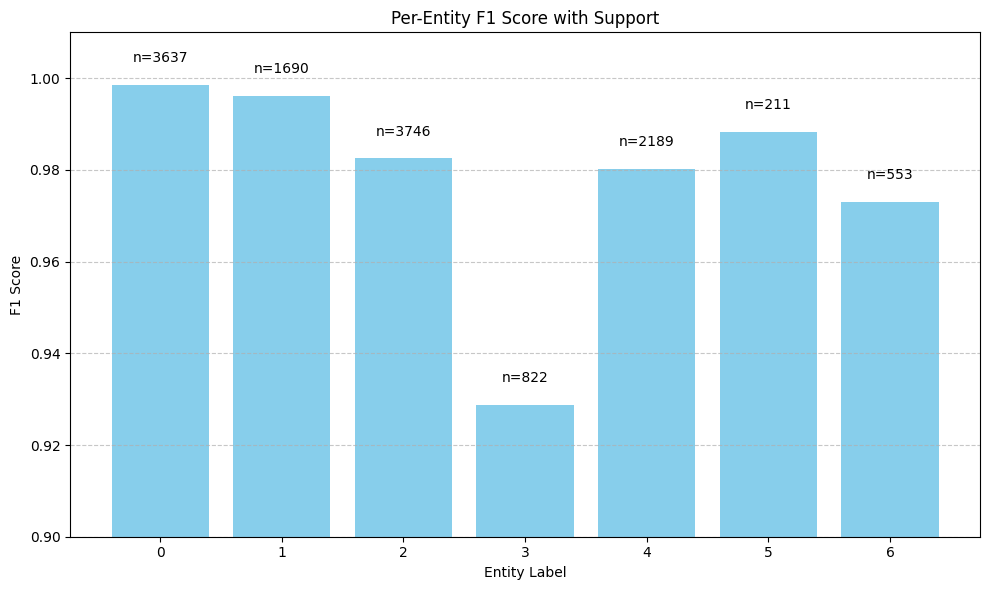

In [19]:
import matplotlib.pyplot as plt

# Example data based on your screenshot
labels = ['0', '1', '2', '3', '4', '5', '6']
f1_scores = [0.9986, 0.9962, 0.9825, 0.9288, 0.9802, 0.9882, 0.9731]
support = [3637, 1690, 3746, 822, 2189, 211, 553]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, f1_scores, color='skyblue')

# Annotate with support size
for bar, sup in zip(bars, support):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'n={sup}', ha='center', fontsize=10)

plt.ylim(0.9, 1.01)
plt.title('Per-Entity F1 Score with Support')
plt.xlabel('Entity Label')
plt.ylabel('F1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# plots to make:
- Grouped Bar Chart (Per Entity)
- overall comparison

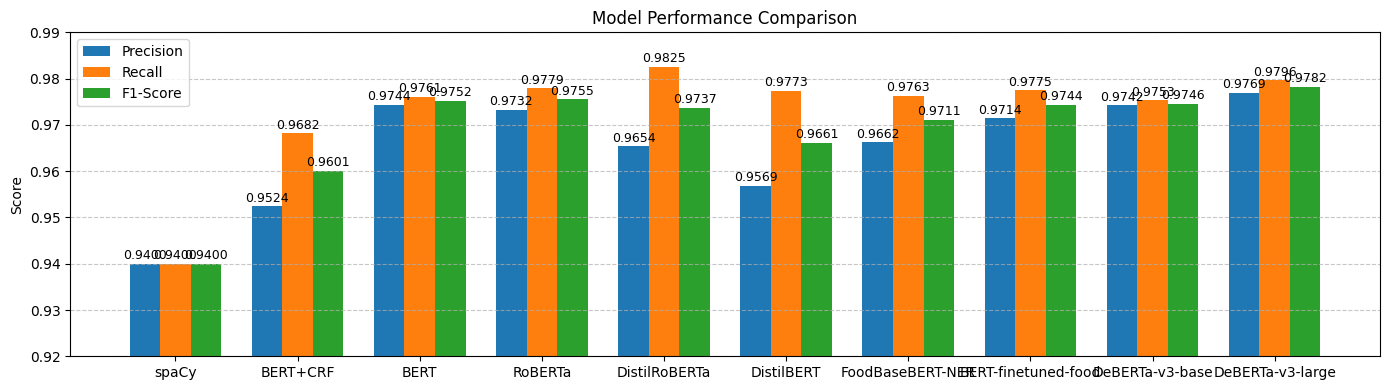

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['spaCy', 'BERT+CRF', 'BERT', 'RoBERTa','DistilRoBERTa','DistilBERT','FoodBaseBERT-NER','BERT-finetuned-food','DeBERTa-v3-base','DeBERTa-v3-large']

# Corresponding metrics
precision = [0.9400, 0.9524, 0.9744, 0.9732,0.9654,0.9569,0.9662,0.9714,0.9742,0.9769]
recall = [0.9400, 0.9682, 0.9761, 0.9779,0.9825,0.9773,0.9763,0.9775,0.9753,0.9796]
f1_score = [0.9400, 0.9601, 0.9752, 0.9755,0.9737,0.9661,0.9711,0.9744,0.9746,0.9782]

# Bar width and position settings
x = np.arange(len(models))
width = 0.25

# Plotting
fig, ax = plt.subplots(figsize=(14, 4))
bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1_score, width, label='F1-Score')

# Annotate bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f'{yval:.4f}', ha='center', fontsize=9)

# Axes labels and formatting
ax.set_ylabel('Score')
ax.set_ylim(0.92, 0.99)
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

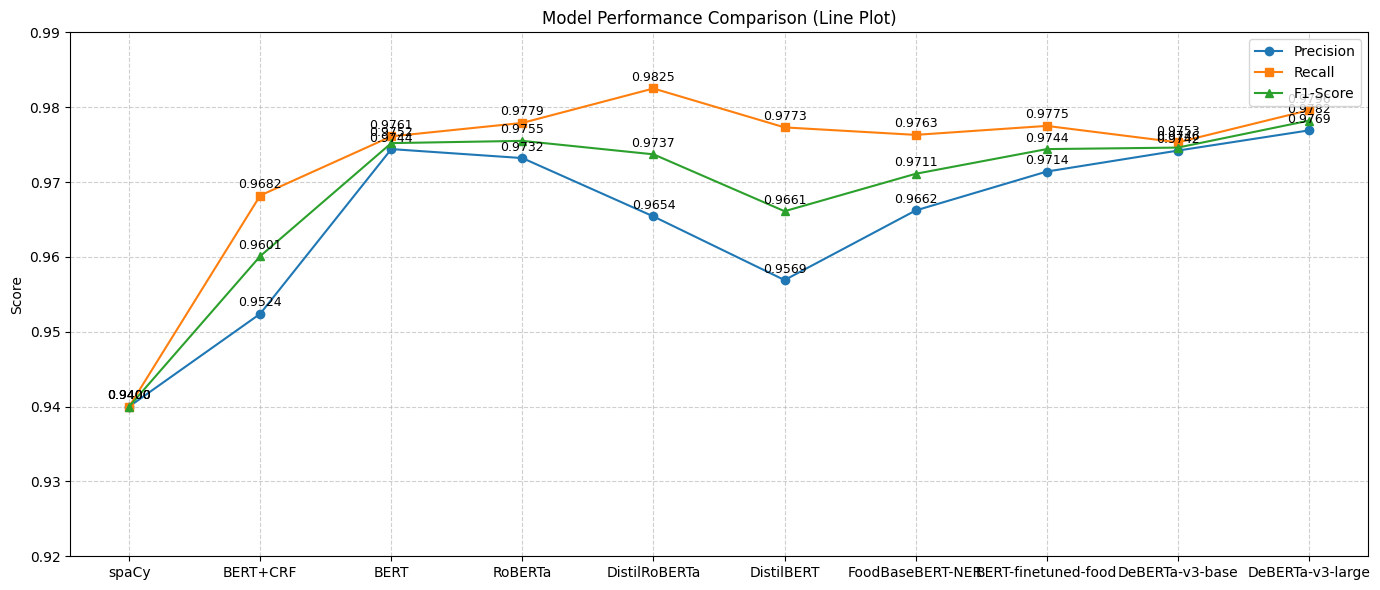

In [26]:
# Plotting
plt.figure(figsize=(14, 6))
plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='s', label='Recall')
plt.plot(models, f1_score, marker='^', label='F1-Score')

# Annotations
for i, model in enumerate(models):
    plt.text(i, precision[i] + 0.001, f"{precision[i]:.4f}", ha='center', fontsize=9)
    plt.text(i, recall[i] + 0.001, f"{recall[i]:.4f}", ha='center', fontsize=9)
    plt.text(i, f1_score[i] + 0.001, f"{f1_score[i]:.4f}", ha='center', fontsize=9)

# Formatting
plt.title('Model Performance Comparison (Line Plot)')
plt.ylabel('Score')
plt.ylim(0.92, 0.99)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import torch
import numpy as np

# Define checkpoint path
checkpoint_path = "../../models/deberta_v3_large/deberta_v3_large_ner.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DebertaNER(tokens_dim=len(label_map))
optimizer = AdamW(model.parameters(), lr=2e-5)

# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)


# Load model and optimizer state
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Ensure model is in evaluation mode
model.to(device)
model.eval()

print("Model loaded successfully and set to evaluation mode!")

Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_282141/596142717.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_gl

Model loaded successfully and set to evaluation mode!


In [7]:
label_map = {
    0: 'QUANTITY',
    1: 'UNIT',
    2: 'NAME',
    3: 'FORM',
    4: 'STATE',
    5: 'DF',
    6: 'SIZE',
    -100: 'O'
}
id2label = {v: k for k, v in label_map.items() if v != -100}
label_names = {k: v for k, v in label_map.items() if k != -100}

In [12]:
from collections import defaultdict

misclassified = defaultdict(list)  # (true_label, pred_label) → list of (tokens, true_label, pred_label)

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        true_labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)

        for i in range(len(input_ids)):
            for j in range(len(input_ids[i])):
                pred_label = preds[i][j].item()
                true_label = true_labels[i][j].item()

                if true_label == -100:
                    continue

                if pred_label != true_label:
                    token = tokenizer.convert_ids_to_tokens(input_ids[i][j].item())
                    misclassified[(true_label, pred_label)].append((token, label_names[true_label], label_names[pred_label]))

In [13]:
target_pair = (4, 2)  # STATE → NAME
if target_pair in misclassified:
    print("Examples of STATE → NAME misclassification:")
    for token, true_tag, pred_tag in misclassified[target_pair][:10]:  # show top 10
        print(f"Token: {token:<12}  True: {true_tag:<8}  Predicted: {pred_tag}")

Examples of STATE → NAME misclassification:
Token: ▁toasted      True: STATE     Predicted: NAME
Token: ▁sweet        True: STATE     Predicted: NAME
Token: ▁sweet        True: STATE     Predicted: NAME
Token: -             True: STATE     Predicted: NAME
Token: ▁mild         True: STATE     Predicted: NAME
Token: ▁herbal       True: STATE     Predicted: NAME
Token: ▁mocha        True: STATE     Predicted: NAME
Token: -             True: STATE     Predicted: NAME
Token: flavored      True: STATE     Predicted: NAME
Token: ▁seasoned     True: STATE     Predicted: NAME


In [16]:
target_pair = (3, 2)  # FORM → NAME
if target_pair in misclassified:
    print("Examples of STATE → NAME misclassification:")
    for token, true_tag, pred_tag in misclassified[target_pair][:10]:  # show top 10
        print(f"Token: {token:<12}  True: {true_tag:<8}  Predicted: {pred_tag}")

Examples of STATE → NAME misclassification:
Token: ▁orange       True: FORM      Predicted: NAME
Token: ▁seeds        True: FORM      Predicted: NAME
Token: ▁seed         True: FORM      Predicted: NAME
Token: ▁seeds        True: FORM      Predicted: NAME
Token: ▁seeds        True: FORM      Predicted: NAME
Token: ▁heart        True: FORM      Predicted: NAME
Token: ▁seeds        True: FORM      Predicted: NAME
Token: ▁seeds        True: FORM      Predicted: NAME
Token: ▁light        True: FORM      Predicted: NAME
Token: ▁cubes        True: FORM      Predicted: NAME


In [ ]:
from huggingface_hub import login, upload_folder

# (optional) Login with your Hugging Face credentials
login()

# Push your dataset files
upload_folder(folder_path="RecipeNER-FG", repo_id="ritisha2703/RecipeNER-FG", repo_type="dataset")
# (HF token removed)

RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6a16947a-434ab3bb115402b63dc44d1c;d5310a89-bc99-4025-b88d-7ba72a2e28a8)

Repository Not Found for url: https://huggingface.co/api/datasets/ritisha2703/RecipeNER-FG/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated.
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.